## Convolutional neural network

A cnn for better deblurring performance than the MLP

In [1]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle

In [2]:
# the CNN model for better deblurring performance
class DeblurCNN(nn.Module):
    def __init__(self):
        super(DeblurCNN, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=7, padding=3),
        )
    
    def forward(self, x):
        # x shape: (batch_size, signal_length)
        x = x.unsqueeze(1)  
        x = self.encoder(x)
        x = self.decoder(x)
        return x.squeeze(1)  

In [3]:
# Preparing the training data into training and testing segments

def prepre_train_test_data(training_data, test_size, seed=42):

    blur_cols = [col for col in training_data.columns if 'y_blur' in col]
    clean_cols = [col for col in training_data.columns if 'y_clean' in col]

    blur_cols.sort(key=lambda x: int(x.split('_')[-1]))
    clean_cols.sort(key=lambda x: int(x.split('_')[-1]))

    X = training_data[blur_cols].values.T
    y = training_data[clean_cols].values.T

    # split_idx = int((1 - test_size) * len(X))
    
    # X_train = X[:split_idx]
    # y_train = y[:split_idx]
    # X_test = X[split_idx:]
    # y_test = y[split_idx:]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

    X_train = torch.FloatTensor(X_train)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.FloatTensor(y_train)
    y_test = torch.FloatTensor(y_test)

    return X_train, X_test, y_train, y_test


In [4]:
# training the model and calculating loss

def train_model(model, X_train, y_train, X_test, y_test, epochs=1000, batch_size=32, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)

    train_losses = []
    test_losses = []
    
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)

        avg_train_loss = epoch_loss / len(X_train)
        train_losses.append(avg_train_loss)
        
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test).item()
            test_losses.append(test_loss)
        
        if (epoch+1) % 1 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
    return train_losses, test_losses



In [5]:
# visualising the loss 

def visualise_training(train_losses, test_losses):

    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MSE Loss', fontsize=12)
    plt.yscale('log')
    plt.title('Training and Test Loss Over Time', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Final Training Loss: {train_losses[-1]:.6f}")
    print(f"Final Test Loss: {test_losses[-1]:.6f}")

Epoch [1/10], Train Loss: 0.0192, Test Loss: 0.0015
Epoch [2/10], Train Loss: 0.0008, Test Loss: 0.0006
Epoch [3/10], Train Loss: 0.0005, Test Loss: 0.0005
Epoch [4/10], Train Loss: 0.0005, Test Loss: 0.0005
Epoch [5/10], Train Loss: 0.0004, Test Loss: 0.0004
Epoch [6/10], Train Loss: 0.0004, Test Loss: 0.0004
Epoch [7/10], Train Loss: 0.0004, Test Loss: 0.0004
Epoch [8/10], Train Loss: 0.0004, Test Loss: 0.0003
Epoch [9/10], Train Loss: 0.0004, Test Loss: 0.0004
Epoch [10/10], Train Loss: 0.0004, Test Loss: 0.0003


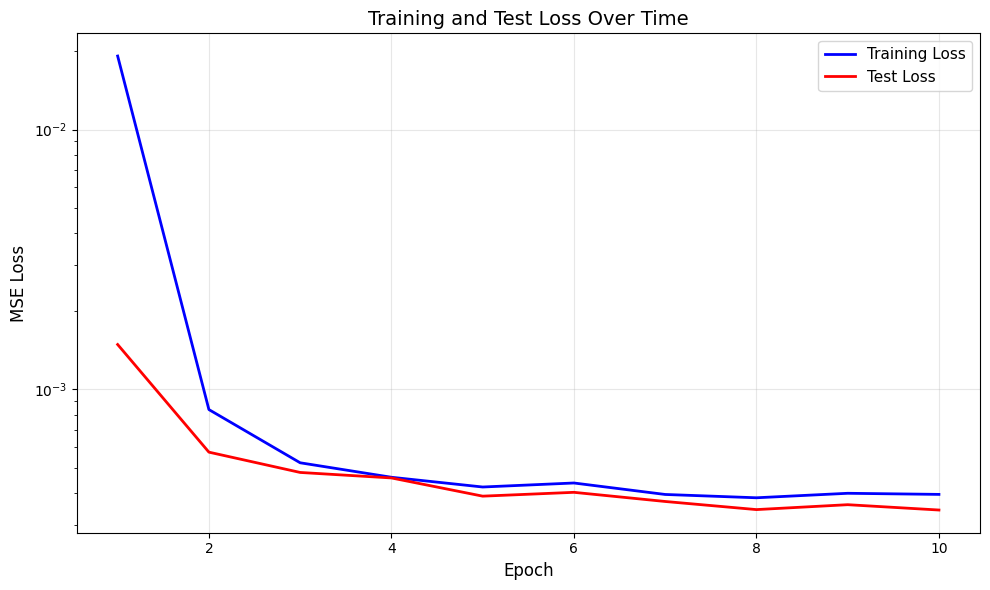

Final Training Loss: 0.000395
Final Test Loss: 0.000344


In [344]:
# Running the full process

filepath = "C:\\Users\\Jpjha\\OneDrive\\Desktop\\Decon by ML\\Code\\training_data.pkl"
training_data = pd.read_pickle(filepath)

X_train, X_test, y_train, y_test = prepre_train_test_data(training_data, test_size=0.2, seed=42)

# model = DeblurMLP(input_size=500, hidden_size1=256, hidden_size2=128, output_size=500)

model = DeblurCNN()

train_losses, test_losses = train_model(model=model,X_train=X_train,y_train=y_train, X_test=X_test,
                                         y_test=y_test, epochs=10, batch_size=32, lr=0.001)

visualise_training(train_losses, test_losses)

torch.save(model.state_dict(), 'deblur_model.pth')

In [6]:
def validate_and_visualise(model, blur_tensors, clean_tensors):

    # blur_cols = [col for col in validation_data.columns if 'y_blur' in col]
    # clean_cols = [col for col in validation_data.columns if 'y_clean' in col]

    # blur_cols.sort(key=lambda x: int(x.split('_')[-1]))
    # clean_cols.sort(key=lambda x: int(x.split('_')[-1]))
    
    # # Extract the actual DATA from these columns (not just the names)
    # blur_data = validation_data[blur_cols].values.T  # Transpose so each row is a signal
    # clean_data = validation_data[clean_cols].values.T
    
    # # Convert to tensors
    # blur_tensors = torch.FloatTensor(blur_data)
    # clean_tensors = torch.FloatTensor(clean_data)
    
    # Run through model
    with torch.no_grad():
        deblurred_signals = model(blur_tensors)
    
    # Convert to numpy for plotting
    blurred_np = blur_tensors.numpy()
    clean_np = clean_tensors.numpy()
    deblurred_np = deblurred_signals.numpy()
    
    # Calculate metrics for each signal
    mse_values = []
    for i in range(len(deblurred_np)):
        mse = np.mean((deblurred_np[i] - clean_np[i]) ** 2)
        mse_values.append(mse)
    
    # Create figure with subplots (2 columns, 5 rows for 8 signals)
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    axes = axes.flatten()
    
    for i in range(8):
        ax = axes[i]
        
        # Plot all three signals
        ax.plot(validation_data['x'], clean_np[i], 'g-', label='Clean (Ground Truth)', 
                linewidth=2, alpha=0.8)
        ax.plot(validation_data['x'], blurred_np[i], 'r--', label='Blurred + Noisy', 
                linewidth=1.5, alpha=0.7)
        ax.plot(validation_data['x'], deblurred_np[i], 'b-', label='Deblurred (Model)', 
                linewidth=2, alpha=0.8)
        
        ax.set_xlabel('x', fontsize=10)
        ax.set_ylabel('Signal Value', fontsize=10)
        ax.set_title(f'Validation Signal {i+1} (MSE: {mse_values[i]:.6f})', fontsize=11)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()
    
   
    return deblurred_np, mse_values






In [346]:
vlaidation_data = pd.read_pickle("C:\\Users\\Jpjha\\OneDrive\\Desktop\\Decon by ML\\Code\\validation_data.pkl")
validate_and_visualise(model, vlaidation_data)

TypeError: validate_and_visualise() missing 1 required positional argument: 'clean_tensors'

In [19]:
torch.save(model, 'deblur_cnn_model_complete.pth')

## Now with data from synthetic MCPs:

In [347]:

with open('nickel_mcp_train_4000.pkl', 'rb') as f:
    train_data = pickle.load(f)
    
with open('nickel_mcp_test_1000.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Extract numpy arrays - DON'T add channel dimension!
# The model's forward() method handles this
X_train = train_data['blur_noisy']  # (4000, 401)
y_train = train_data['clean']       # (4000, 401)
X_test = test_data['blur_noisy']    # (1000, 401)
y_test = test_data['clean']         # (1000, 401)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print(f"Training: {X_train.shape} -> {y_train.shape}")
print(f"Test: {X_test.shape} -> {y_test.shape}")


Training: torch.Size([4000, 401]) -> torch.Size([4000, 401])
Test: torch.Size([1000, 401]) -> torch.Size([1000, 401])


Epoch [1/5], Train Loss: 0.0190, Test Loss: 0.0008
Epoch [2/5], Train Loss: 0.0006, Test Loss: 0.0005
Epoch [3/5], Train Loss: 0.0005, Test Loss: 0.0005
Epoch [4/5], Train Loss: 0.0005, Test Loss: 0.0005
Epoch [5/5], Train Loss: 0.0005, Test Loss: 0.0005


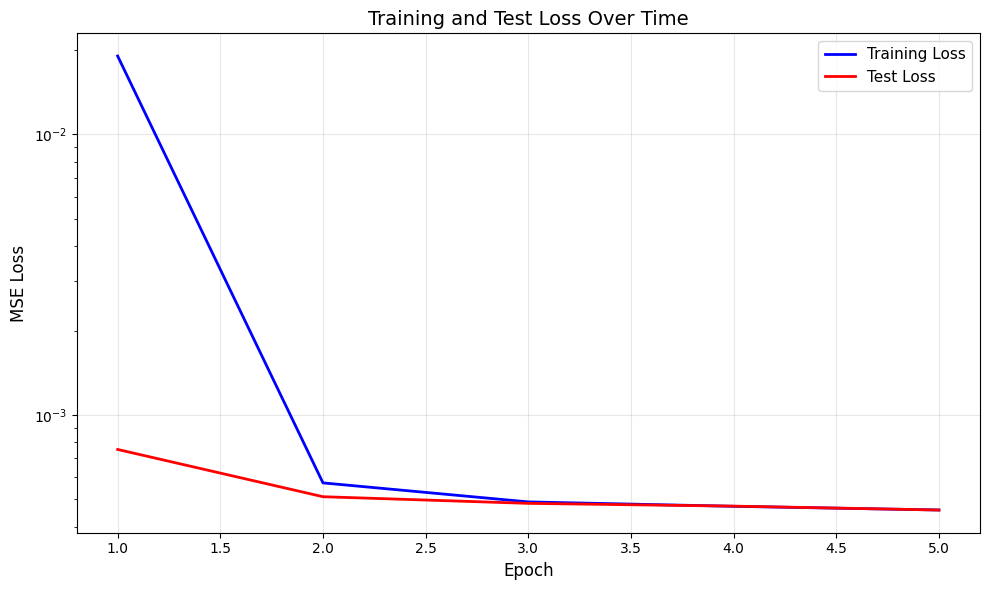

Final Training Loss: 0.000459
Final Test Loss: 0.000459


In [348]:
model = DeblurCNN()

train_losses, test_losses = train_model(model=model,X_train=X_train,y_train=y_train, X_test=X_test,
                                         y_test=y_test, epochs=5, batch_size=32, lr=0.001)

visualise_training(train_losses, test_losses)

In [349]:
with open('nickel_mcp_viz_4samples.pkl', 'rb') as f:
      viz_data = pickle.load(f)

X_viz = viz_data['blur_noisy']  
y_viz = viz_data['clean']       


def validate_and_visualise(model, blurred_tensors, clean_tensors, pz_grid):
    """
    Validate the model and visualize results.
    
    Args:
        model: trained PyTorch model
        blurred_tensors: input data (blurred + noisy)
        clean_tensors: ground truth (clean)
        pz_grid: momentum grid for x-axis
    """
    model.eval()
    
    with torch.no_grad():
        # Get model predictions
        deblurred_tensors = model(blurred_tensors)
    
    # Convert to numpy for plotting
    clean_np = clean_tensors.cpu().numpy()
    blurred_np = blurred_tensors.cpu().numpy()
    deblurred_np = deblurred_tensors.cpu().numpy()
    
    # Calculate metrics
    mse = np.mean((deblurred_np - clean_np)**2, axis=1)
    mae = np.mean(np.abs(deblurred_np - clean_np), axis=1)
    
    # Create figure
    n_samples = len(clean_tensors)
    fig, axes = plt.subplots(n_samples, 1, figsize=(10, 4*n_samples))
    
    if n_samples == 1:
        axes = [axes]
    
    for i in range(n_samples):
        ax = axes[i]
        
        # Plot all three signals
        ax.plot(pz_grid, clean_np[i], 'g-', label='Clean (Ground Truth)', 
                linewidth=2, alpha=0.8)
        ax.plot(pz_grid, blurred_np[i], 'r--', label='Blurred + Noisy', 
                linewidth=1.5, alpha=0.7)
        ax.plot(pz_grid, deblurred_np[i], 'b-', label='Deblurred (Model)', 
                linewidth=2, alpha=0.8)
        
        # Formatting
        ax.set_xlabel('Momentum pz (a.u.)', fontsize=12)
        ax.set_ylabel('MCP (normalized)', fontsize=12)
        ax.set_title(f'Sample {i+1} | MSE: {mse[i]:.6f} | MAE: {mae[i]:.6f}', 
                    fontsize=13)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.5)
        ax.set_xlim(pz_grid.min(), pz_grid.max())
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("VALIDATION SUMMARY")
    print("="*60)
    print(f"Number of samples: {n_samples}")
    print(f"Average MSE: {np.mean(mse):.6f}")
    print(f"Average MAE: {np.mean(mae):.6f}")
    print(f"Min MSE: {np.min(mse):.6f}")
    print(f"Max MSE: {np.max(mse):.6f}")
    print("="*60)
    
    return deblurred_np, mse, mae

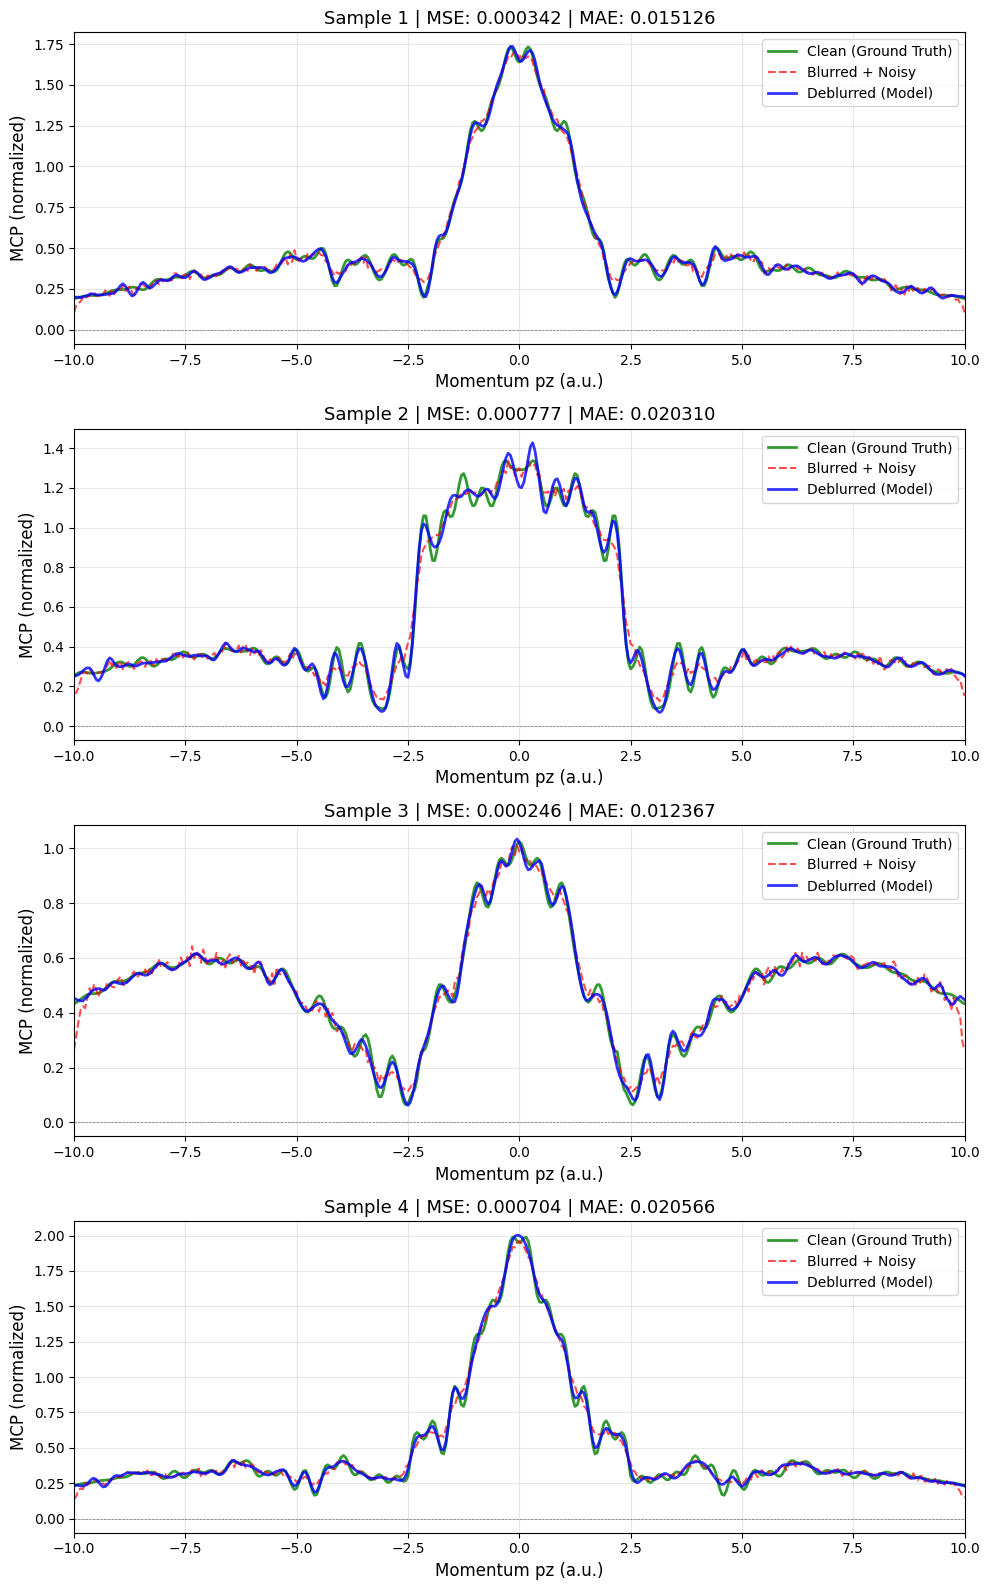


VALIDATION SUMMARY
Number of samples: 4
Average MSE: 0.000517
Average MAE: 0.017092
Min MSE: 0.000246
Max MSE: 0.000777


In [350]:
# Load visualization data
with open('nickel_mcp_viz_4samples.pkl', 'rb') as f:
    viz_data = pickle.load(f)

X_viz = viz_data['blur_noisy']  # Inputs (4, 401)
y_viz = viz_data['clean']       # Targets (4, 401)
pz = viz_data['pz']             # Momentum grid (401,)

# Convert to tensors
blur_tensors = torch.FloatTensor(X_viz)
clean_tensors = torch.FloatTensor(y_viz)

# Validate and visualize
deblurred, mse, mae = validate_and_visualise(model, blur_tensors, clean_tensors, pz)

The model shows substantial gaps in its fitting of signals even after the number of epochs has been optimised to reduce trainoing errors. 

## Adding adaptations to the CNN architecture

The neural net can do with some imporvements, firstly I'm going to add skip connections to see if this helps it recover finer features aswell as large scale ones

In [7]:
class DeblurUnet(nn.Module):
    def __init__(self):
        super(DeblurUnet, self).__init__()
        
        self.enc1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.ReLU(),)
        
        self.enc2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.enc3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),)
        

        self.dec1 = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec2 = nn.Sequential(
            nn.Conv1d(256, 64, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec3 = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(),)

        self.final = nn.Conv1d(64, 1, kernel_size=7, padding=3)        
        
    
    
    def forward(self, x):
        
        x_input = x.unsqueeze(1)
                
        e1 = self.enc1(x_input)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
               
        d1 = self.dec1(e3)
        d2 = self.dec2(torch.cat([d1, e2], dim=1))
        d3 = self.dec3(torch.cat([d2, e1], dim=1))
               
        output = self.final(d3)
        output = output.squeeze(1)
               
        output = x + 0.1 * output
        
        return output

Training: torch.Size([4000, 401]) -> torch.Size([4000, 401])
Test: torch.Size([1000, 401]) -> torch.Size([1000, 401])
Epoch [1/5], Train Loss: 0.0006, Test Loss: 0.0003
Epoch [2/5], Train Loss: 0.0003, Test Loss: 0.0003
Epoch [3/5], Train Loss: 0.0003, Test Loss: 0.0003
Epoch [4/5], Train Loss: 0.0003, Test Loss: 0.0003
Epoch [5/5], Train Loss: 0.0003, Test Loss: 0.0003


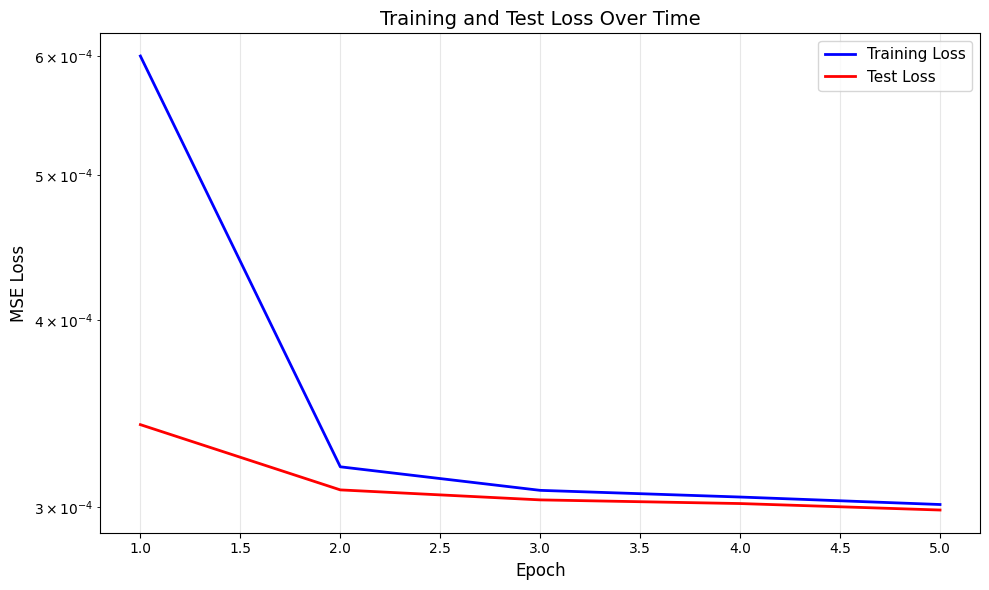

Final Training Loss: 0.000301
Final Test Loss: 0.000299


In [386]:
with open('nickel_mcp_train_4000.pkl', 'rb') as f:
    train_data = pickle.load(f)
    
with open('nickel_mcp_test_1000.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Extract numpy arrays - DON'T add channel dimension!
# The model's forward() method handles this
X_train = train_data['blur_noisy']  # (4000, 401)
y_train = train_data['clean']       # (4000, 401)
X_test = test_data['blur_noisy']    # (1000, 401)
y_test = test_data['clean']         # (1000, 401)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print(f"Training: {X_train.shape} -> {y_train.shape}")
print(f"Test: {X_test.shape} -> {y_test.shape}")

model = DeblurUnet()

train_losses, test_losses = train_model(model=model,X_train=X_train,y_train=y_train, X_test=X_test,
                                         y_test=y_test, epochs=5, batch_size=32, lr=0.001)

visualise_training(train_losses, test_losses)

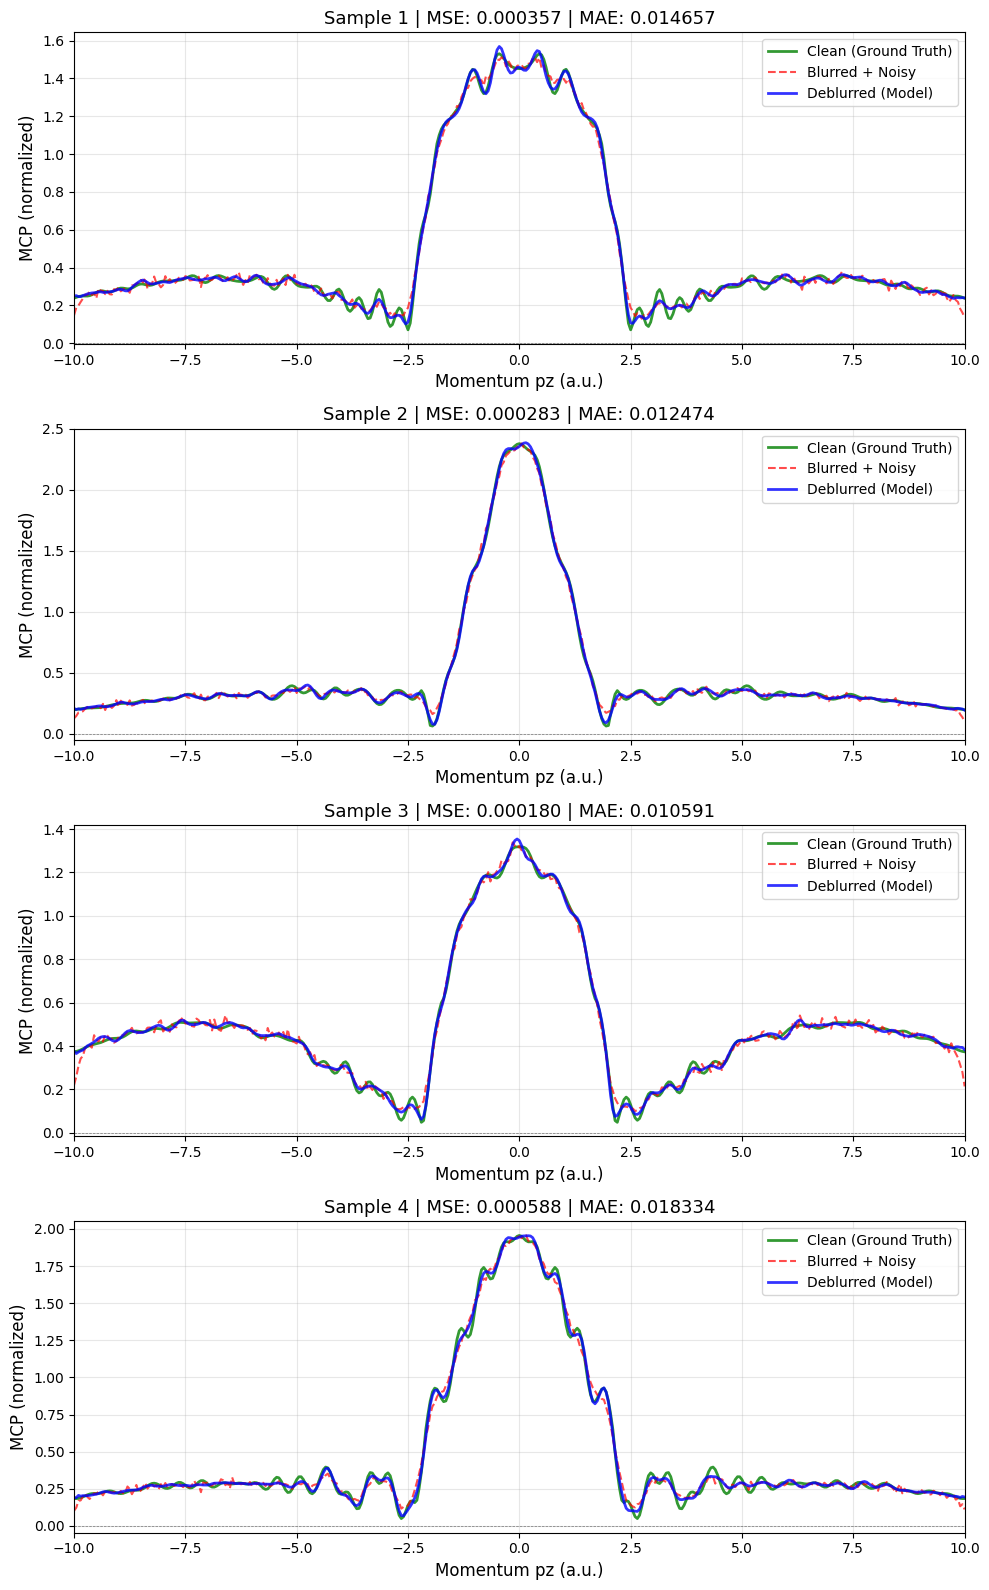


VALIDATION SUMMARY
Number of samples: 4
Average MSE: 0.000352
Average MAE: 0.014014
Min MSE: 0.000180
Max MSE: 0.000588


In [374]:
with open('nickel_mcp_viz_4samples.pkl', 'rb') as f:
    viz_data = pickle.load(f)

X_viz = viz_data['blur_noisy']  # Inputs (4, 401)
y_viz = viz_data['clean']       # Targets (4, 401)
pz = viz_data['pz']             # Momentum grid (401,)

# Convert to tensors
blur_tensors = torch.FloatTensor(X_viz)
clean_tensors = torch.FloatTensor(y_viz)

# Validate and visualize
deblurred, mse, mae = validate_and_visualise(model, blur_tensors, clean_tensors, pz)

This U net architecture improves the training loss significantly, next to test it on actual MCP data

## Real Nickel MCPs:

Nickel from [100], [110] and [111] directions:

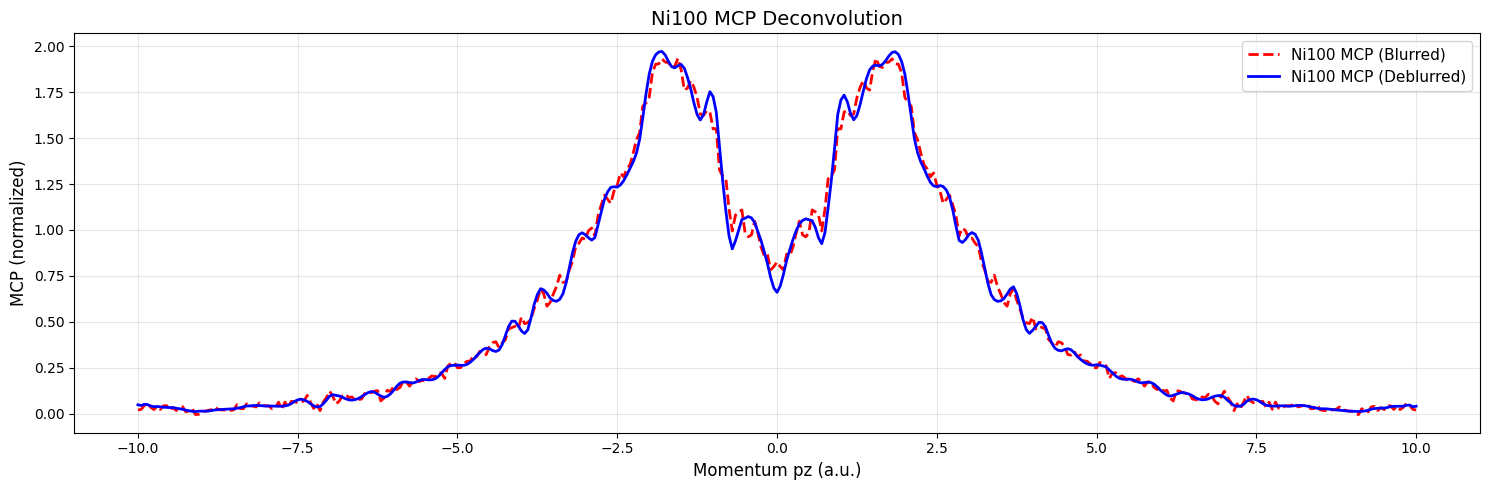

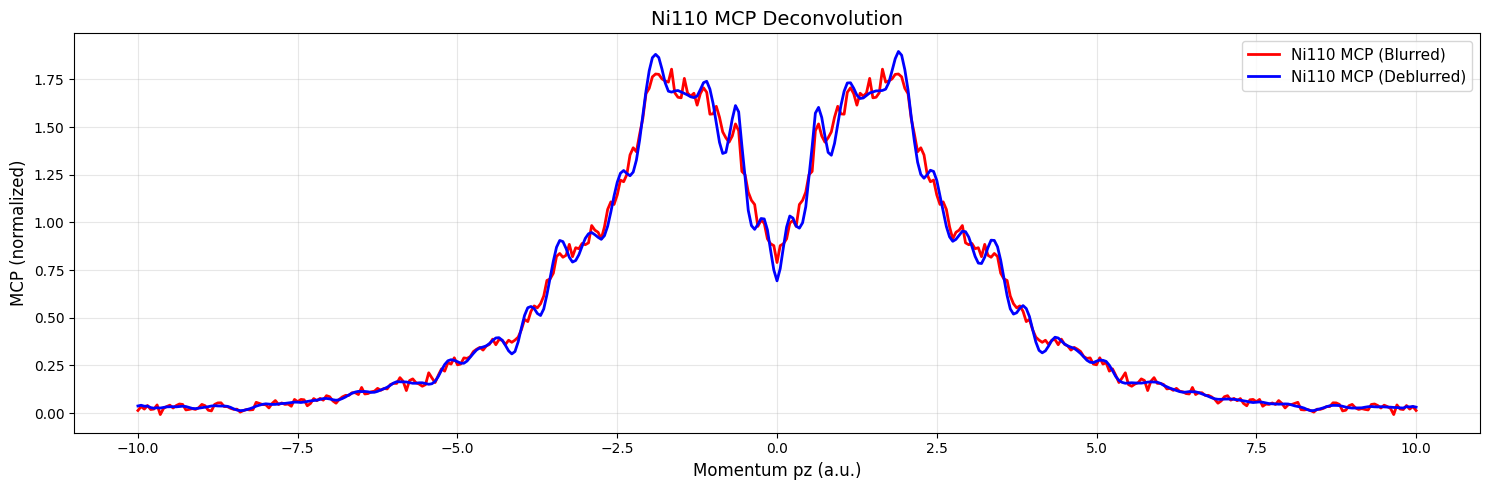

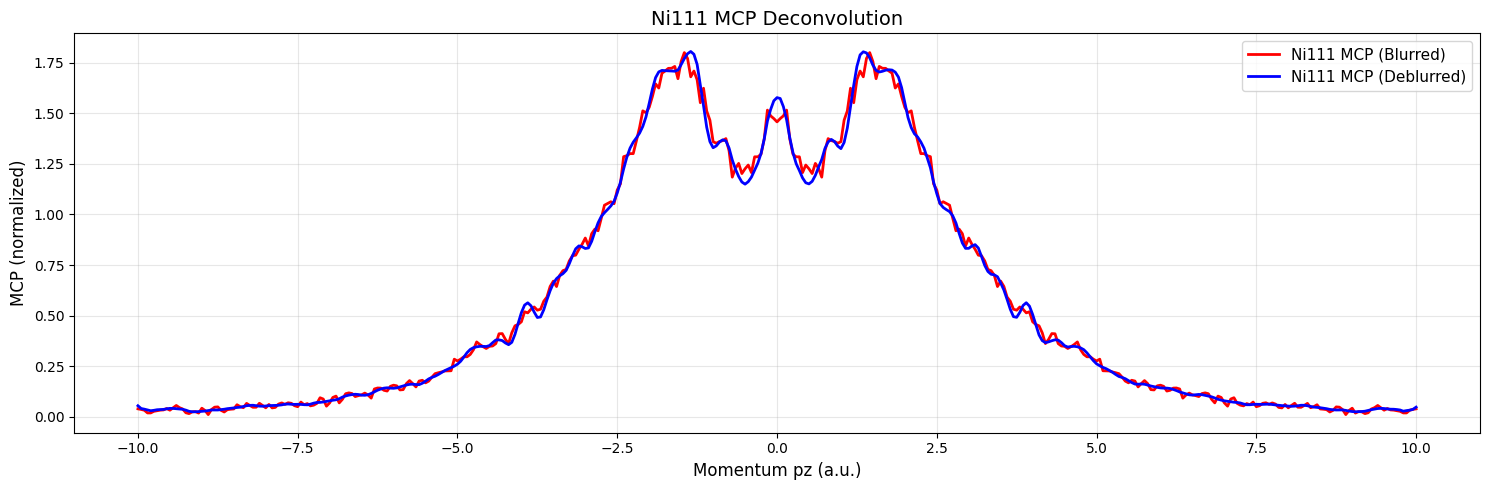

In [387]:
ni100 = np.loadtxt('Ni_Magnetic_Compton/ni100ts_witherrors.dat')
ni110 = np.loadtxt('Ni_Magnetic_Compton/ni110ts_witherrors.dat')
ni111 = np.loadtxt('Ni_Magnetic_Compton/ni111ts_witherrors.dat')

pz = ni100[:,0]
mcp100 = ni100[:,1] * 10
mcp110 = ni110[:,1] * 10
mcp111 = ni111[:,1] * 10 

blur_tensors_100 = torch.FloatTensor(mcp100).unsqueeze(0)
blur_tensors_110 = torch.FloatTensor(mcp110).unsqueeze(0)
blur_tensors_111 = torch.FloatTensor(mcp111).unsqueeze(0)

model.eval()
with torch.no_grad():
    deblurred_100 = model(blur_tensors_100).squeeze(0).numpy()
    deblurred_110 = model(blur_tensors_110).squeeze(0).numpy()
    deblurred_111 = model(blur_tensors_111).squeeze(0).numpy()


for i in range(3):
    plt.figure(figsize=(15, 5))
    if i == 0:
        plt.plot(pz, mcp100, 'r--', label='Ni100 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_100, 'b-', label='Ni100 MCP (Deblurred)', linewidth=2)
        plt.title('Ni100 MCP Deconvolution', fontsize=14)
    elif i == 1:
        plt.plot(pz, mcp110, 'r', label='Ni110 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_110, 'b-', label='Ni110 MCP (Deblurred)', linewidth=2)
        plt.title('Ni110 MCP Deconvolution', fontsize=14)
    else:
        plt.plot(pz, mcp111, 'r', label='Ni111 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_111, 'b-', label='Ni111 MCP (Deblurred)', linewidth=2)
        plt.title('Ni111 MCP Deconvolution', fontsize=14)

    plt.xlabel('Momentum pz (a.u.)', fontsize=12)
    plt.ylabel('MCP (normalized)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Use theoretical EMDs to create compton profiles


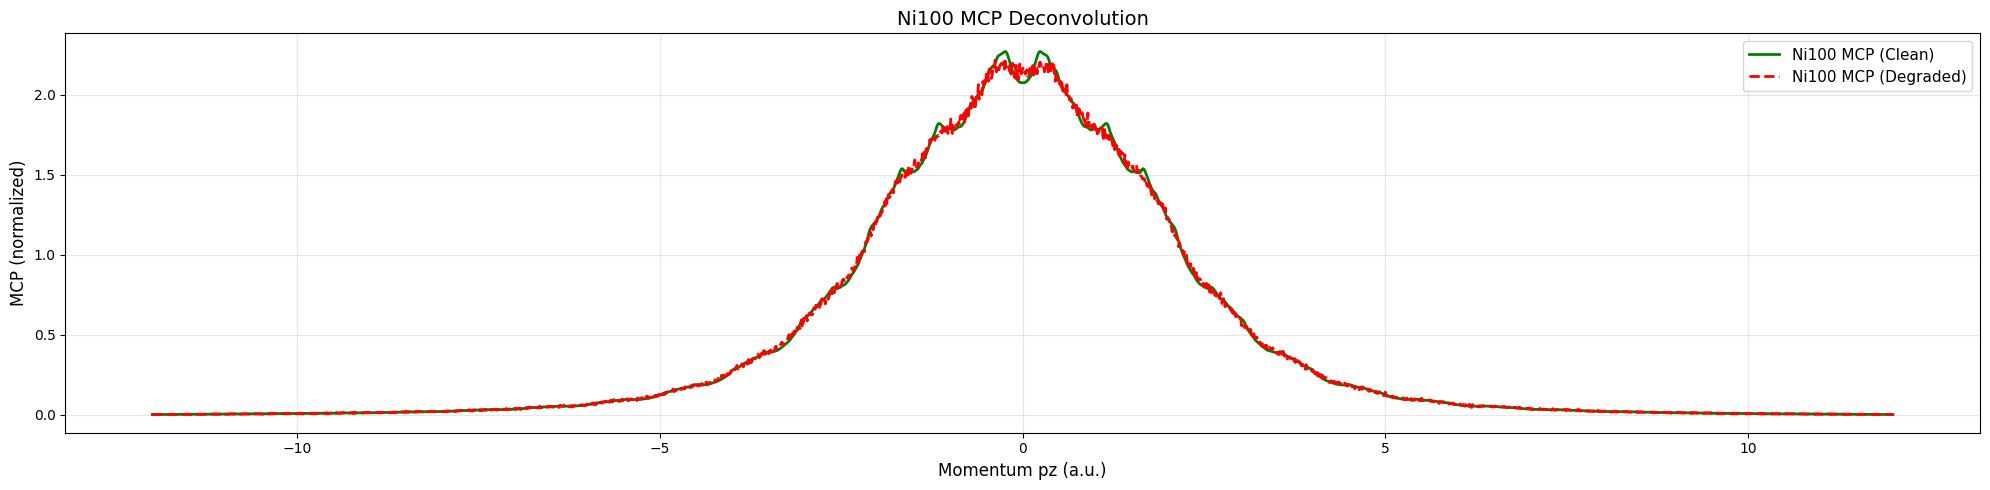

In [394]:
with open('Nickel_100_profiles.pkl', 'rb') as f:
    theory_100 = pickle.load(f)

with open('Nickel_111_profiles.pkl', 'rb') as f:
    theory_111 = pickle.load(f)

pz = theory_100['pz']
clean_100 = theory_100['mcp_clean'] * 1e3
clean_111 = theory_111['mcp_clean'] * 1e3
degraded_100 = theory_100['mcp_blur_noisy'] * 1e3
degraded_111 = theory_111['mcp_blur_noisy'] * 1e3

blur_tensors_100 = torch.FloatTensor(degraded_100).unsqueeze(0)
blur_tensors_111 = torch.FloatTensor(degraded_111).unsqueeze(0)

model.eval()
with torch.no_grad():
    deblurred_100 = model(blur_tensors_100).squeeze(0).numpy()
    deblurred_111 = model(blur_tensors_111).squeeze(0).numpy()

plt.figure(figsize=(20, 5))
plt.plot(pz, clean_100, 'g-', label='Ni100 MCP (Clean)', linewidth=2)
plt.plot(pz, degraded_100, 'r--', label='Ni100 MCP (Degraded)', linewidth=2)
#plt.plot(pz, deblurred_100, 'b-', label='Ni100 MCP (Deblurred)', linewidth=2)
plt.title('Ni100 MCP Deconvolution', fontsize=14)
plt.xlabel('Momentum pz (a.u.)', fontsize=12)
plt.ylabel('MCP (normalized)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Training and tetsing using the filtered synthetic MCP dataset

Training: torch.Size([3000, 2401]) -> torch.Size([3000, 2401])
Test: torch.Size([1000, 2401]) -> torch.Size([1000, 2401])
Epoch [1/5], Train Loss: 0.0003, Test Loss: 0.0002
Epoch [2/5], Train Loss: 0.0001, Test Loss: 0.0000
Epoch [3/5], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [4/5], Train Loss: 0.0000, Test Loss: 0.0000
Epoch [5/5], Train Loss: 0.0000, Test Loss: 0.0000


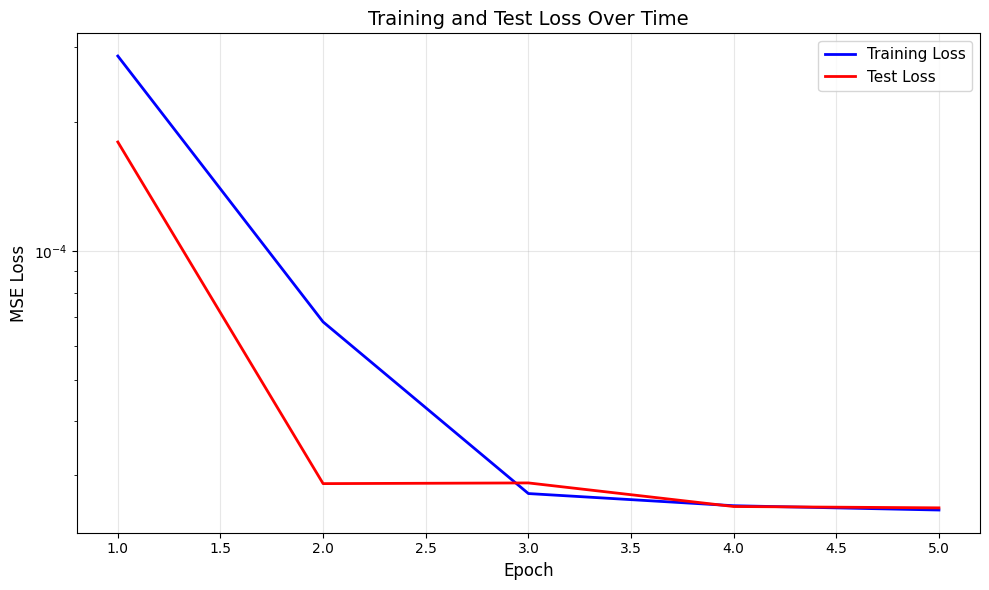

Final Training Loss: 0.000025
Final Test Loss: 0.000025


In [8]:
with open('nickel_mcp_train_filtered_4000.pkl', 'rb') as f:
    train_data = pickle.load(f)
    
with open('nickel_mcp_test_filtered_1000.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Extract numpy arrays - DON'T add channel dimension!
# The model's forward() method handles this
X_train = train_data['blur_noisy']  # (4000, 401)
y_train = train_data['clean']       # (4000, 401)
X_test = test_data['blur_noisy']    # (1000, 401)
y_test = test_data['clean']         # (1000, 401)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print(f"Training: {X_train.shape} -> {y_train.shape}")
print(f"Test: {X_test.shape} -> {y_test.shape}")

model = DeblurUnet()

train_losses, test_losses = train_model(model=model,X_train=X_train,y_train=y_train, X_test=X_test,
                                         y_test=y_test, epochs=5, batch_size=32, lr=0.001)

visualise_training(train_losses, test_losses)

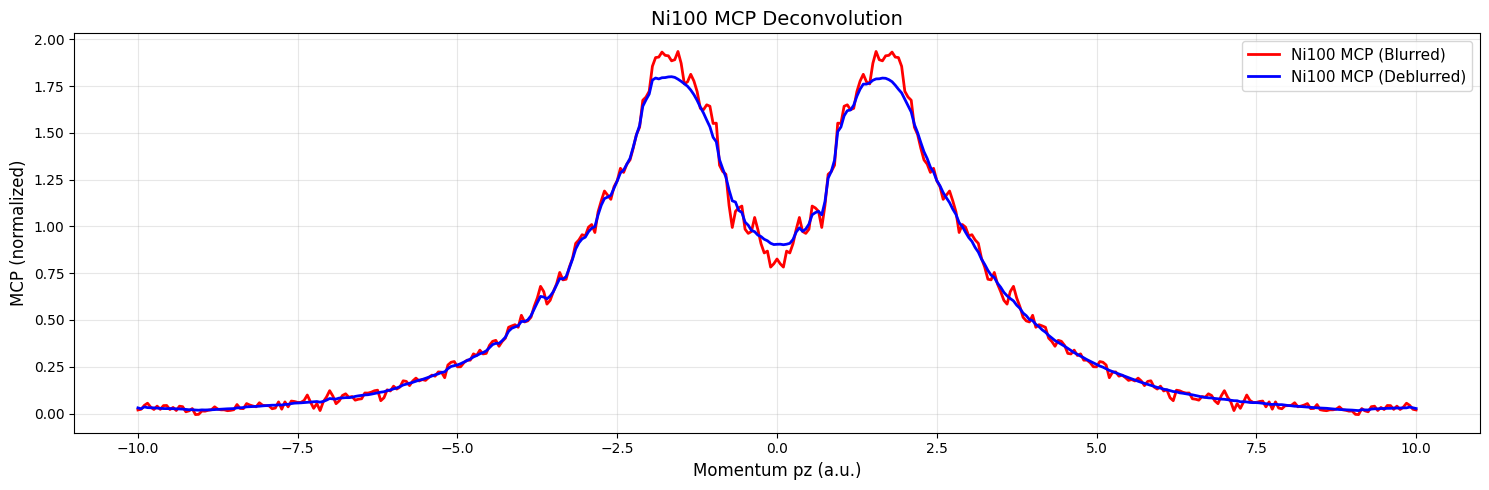

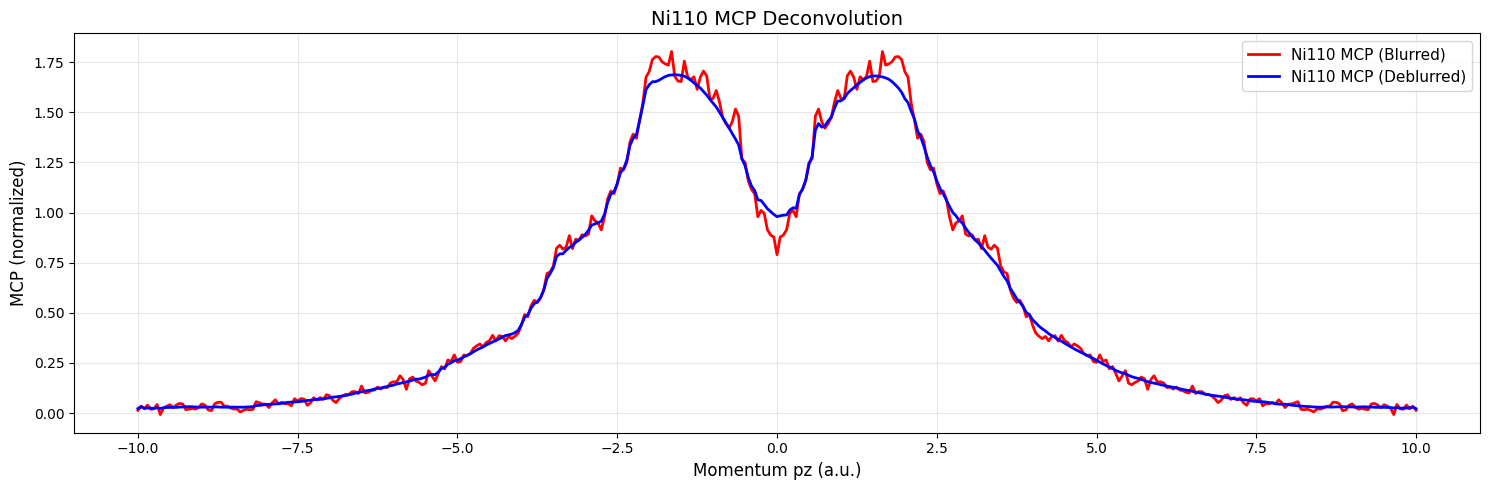

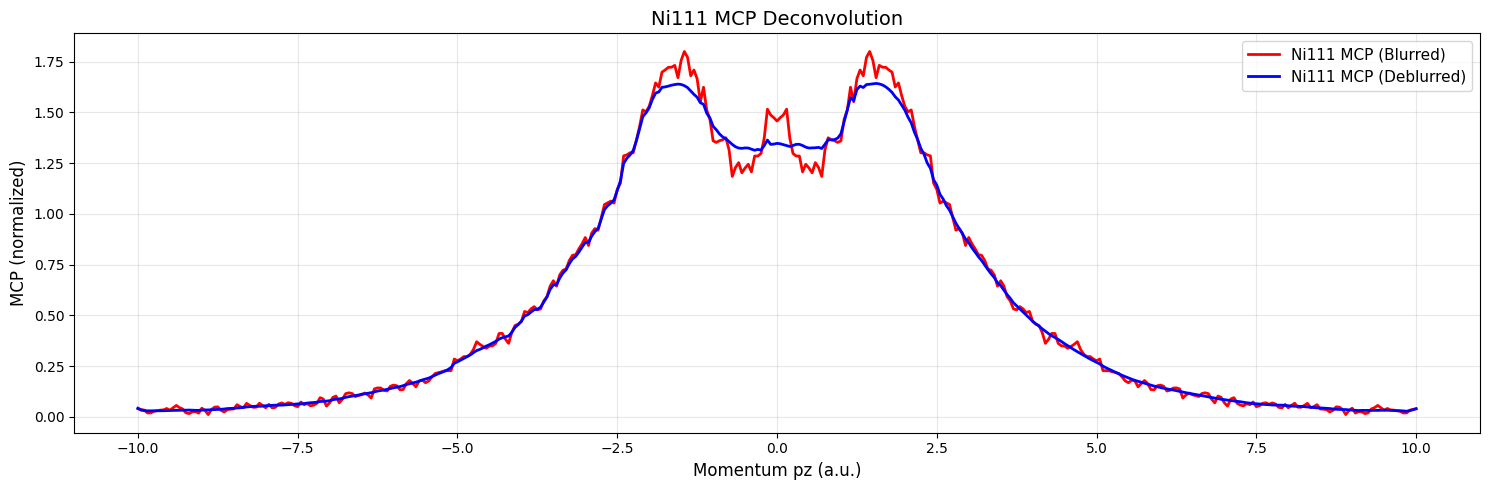

In [10]:
ni100 = np.loadtxt('Ni_Magnetic_Compton/ni100ts_witherrors.dat')
ni110 = np.loadtxt('Ni_Magnetic_Compton/ni110ts_witherrors.dat')
ni111 = np.loadtxt('Ni_Magnetic_Compton/ni111ts_witherrors.dat')

pz = ni100[:,0]
mcp100 = ni100[:,1] * 10
mcp110 = ni110[:,1] * 10
mcp111 = ni111[:,1] * 10 

blur_tensors_100 = torch.FloatTensor(mcp100).unsqueeze(0)
blur_tensors_110 = torch.FloatTensor(mcp110).unsqueeze(0)
blur_tensors_111 = torch.FloatTensor(mcp111).unsqueeze(0)

model.eval()
with torch.no_grad():
    deblurred_100 = model(blur_tensors_100).squeeze(0).numpy()
    deblurred_110 = model(blur_tensors_110).squeeze(0).numpy()
    deblurred_111 = model(blur_tensors_111).squeeze(0).numpy()


for i in range(3):
    plt.figure(figsize=(15, 5))
    if i == 0:
        plt.plot(pz, mcp100, 'r', label='Ni100 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_100, 'b-', label='Ni100 MCP (Deblurred)', linewidth=2)
        plt.title('Ni100 MCP Deconvolution', fontsize=14)
    elif i == 1:
        plt.plot(pz, mcp110, 'r', label='Ni110 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_110, 'b-', label='Ni110 MCP (Deblurred)', linewidth=2)
        plt.title('Ni110 MCP Deconvolution', fontsize=14)
    else:
        plt.plot(pz, mcp111, 'r', label='Ni111 MCP (Blurred)', linewidth=2)
        plt.plot(pz, deblurred_111, 'b-', label='Ni111 MCP (Deblurred)', linewidth=2)
        plt.title('Ni111 MCP Deconvolution', fontsize=14)

    plt.xlabel('Momentum pz (a.u.)', fontsize=12)
    plt.ylabel('MCP (normalized)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()